In [2]:
# pip install -r requirements.txt

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import gudhi as gd
import torus as t

from persim import plot_diagrams, bottleneck
from ripser import ripser
from gudhi.datasets.generators import points
from tadasets import torus

In [4]:
rng = np.random.default_rng(0) # reproducability

The boring part...

In [5]:
# generate circle and its noisy counterpart
n = 400
theta = np.linspace(0, 2*np.pi, n, endpoint=False)
circle = np.column_stack([np.cos(theta), np.sin(theta)])
noise = rng.normal(loc=0, scale=0.1, size=circle.shape)
circleNoisy = circle + noise

Checking we have circle...

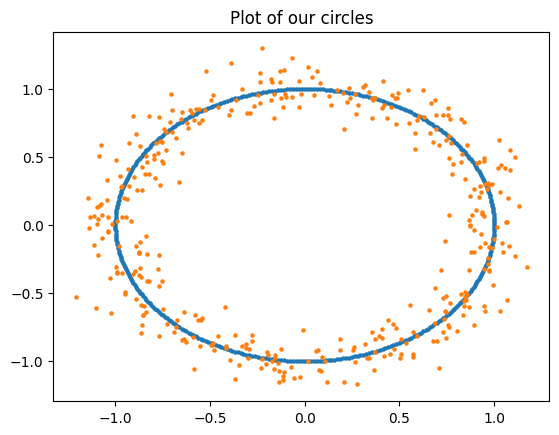

In [6]:
plt.scatter(circle[:,0], circle[:,1], s=5)
plt.scatter(circleNoisy[:,0], circleNoisy[:,1], s=5)
plt.title("Plot of our circles")
plt.show()

now for the fun...

## Key Python package

### Gudhi
- A library for doing all things TDA!
- Is able to compute the persistance homology of a point cloud
- Can use a variety of ways to build the simplicial complices - including the ones mentioned in Needham namely Vietoris-Rips and Alpha Complex
- Is one of the few Python packages able to do the full pipeline - others exist but for individual parts of the pipeline eg `ripser` for computing VR and `persim` for plotting

![TDA pipeline](thePipeline.png)

#### However for the sake of not bricking my computer any VR complex will be run using `ripser` -  something to examine

The below block does the building of the Filtered Simplicial Complex 

In [7]:
ac = gd.AlphaComplex(points=circle) #  note: gd.Rips builds using VR
cleanSt = ac.create_simplex_tree()

This block computes the persitance homology using the gudhi instance of the filtered simplical complex

In [8]:
cleanSt.compute_persistence()

This block does the final step of the pipline and plots our barcode and persistance diagram

C:\Users\john\AppData\Local\Programs\Python\Python312\Lib\site-packages\gudhi\persistence_graphical_tools.py:134: UserWarning: usetex mode requires dvipng.
  warnings.warn("usetex mode requires dvipng.")


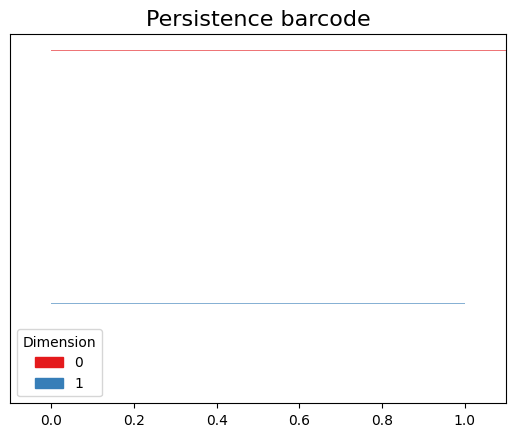

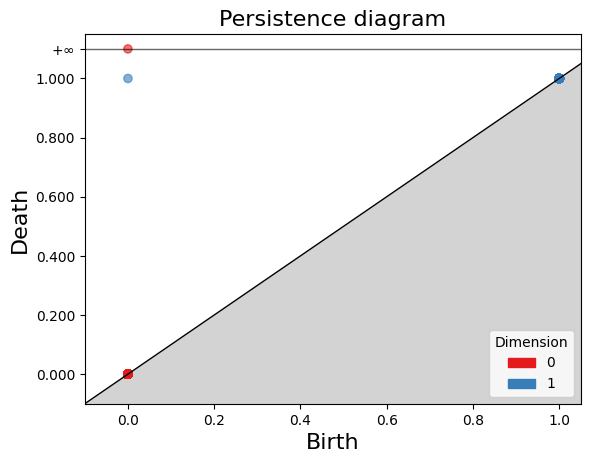

In [9]:
gd.plot_persistence_barcode(cleanSt.persistence())
plt.show()
gd.plot_persistence_diagram(cleanSt.persistence())
plt.show()

For convinience we define the following function to compute the pipeline for a given point cloud 
and type of constructor for simplicial complex

In [10]:
def computePipline(pointCloud, scType, maxDim=2):
    """
    Fucntion for computing persitance and barcode digrams from a point cloud
    Just using Vietoris-Rips and Alpha compelexes to build the simplical complices
    """
    if scType == "VR":
        skel = gd.RipsComplex(points=pointCloud, max_edge_length=2)
        st = skel.create_simplex_tree(max_dimension=maxDim)
    elif scType == "Alpha":
        skel = gd.AlphaComplex(points=pointCloud)
        st = skel.create_simplex_tree()
    else:
        return
    st.compute_persistence()
    persistance = st.persistence() 
    gd.plot_persistence_barcode(persistance)
    plt.show()
    gd.plot_persistence_diagram(persistance)
    plt.show()
    return st

In [11]:
def safeComputePipline(pointCloud, scType, maxDim=1):
    """
    Safe by fact my computer wont blow up trying to do VR
    Fucntion for computing persitance and barcode digrams from a point cloud
    Just using Vietoris-Rips and Alpha compelexes to build the simplical complices
    """
    if scType == "VR":
        res = ripser(pointCloud, maxdim=maxDim)
        dgms = res["dgms"]
        plot_diagrams(dgms)
        plt.show()
        out = {}
        for k in range(len(dgms)):
            out[f"H{k}"] = dgms[k]
        return out
    elif scType == "Alpha":
        skel = gd.AlphaComplex(points=pointCloud)
        st = skel.create_simplex_tree()
        st.compute_persistence()
        persistance = st.persistence() 
        gd.plot_persistence_barcode(persistance)
        plt.show()
        gd.plot_persistence_diagram(persistance)
        plt.show()
        out = {}
        for k in range(maxDim + 1):
            Ik = st.persistence_intervals_in_dimension(k)
            out[f"H{k}"] = Ik if Ik is not None else np.empty((0, 2))
        return out
    return

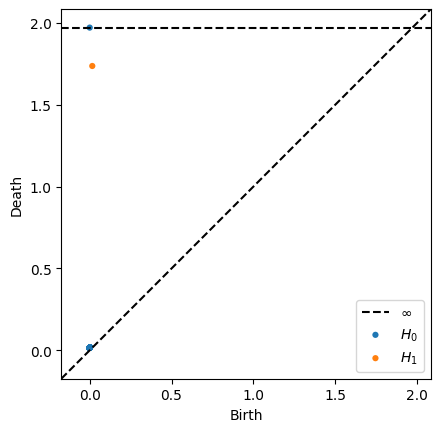

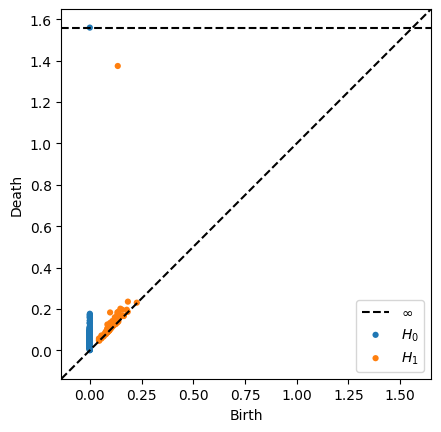

In [12]:
circleH = safeComputePipline(pointCloud=circle, scType='VR')
noisyCircleH = safeComputePipline(pointCloud=circleNoisy, scType='VR')

We note the differences in the two sets of diagrams and now lets compare via our metrics

### Bottleneck distance

In [13]:
circleH0, circleH1 = circleH['H0'], circleH['H1']
noisyCircleH0, noisyCircleH1 = noisyCircleH['H0'], noisyCircleH['H1']
bdH0, bdH1 = bottleneck(circleH0, noisyCircleH0), bottleneck(circleH1, noisyCircleH1)        
print(f"Bottleneck(H0): {bdH0}, Bottleneck(H1): {bdH1}")

C:\Users\john\AppData\Local\Programs\Python\Python312\Lib\site-packages\persim\bottleneck.py:55: UserWarning: dgm1 has points with non-finite death times;ignoring those points
  warnings.warn(
C:\Users\john\AppData\Local\Programs\Python\Python312\Lib\site-packages\persim\bottleneck.py:64: UserWarning: dgm2 has points with non-finite death times;ignoring those points
  warnings.warn(


Bottleneck(H0): 0.08833513408899307, Bottleneck(H1): 0.36268484592437744


----

### Example of a sphere and torus 

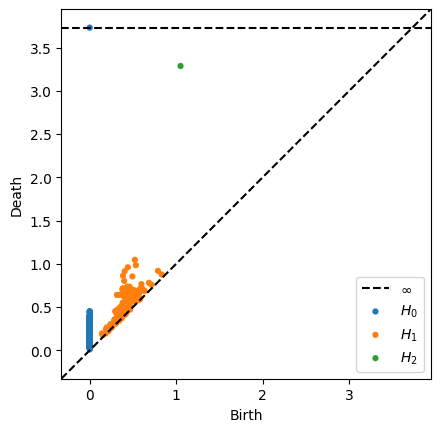

In [22]:
n = 500
sphere = points.sphere(n_samples=n, ambient_dim=3, radius=2)
sphereH = safeComputePipline(pointCloud=sphere, scType='VR', maxDim=2)

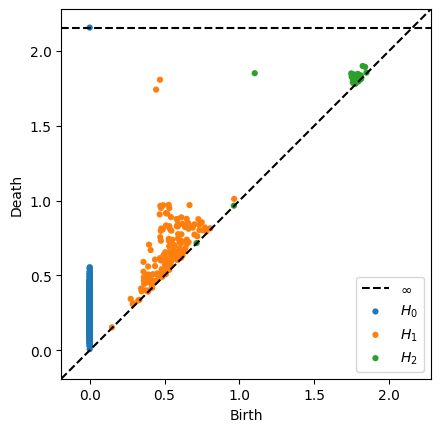

In [23]:
torus3d = torus(n=n, c=2, a=1, seed=42, uniform=True)
torusH = safeComputePipline(pointCloud=torus3d, scType='VR', maxDim=2)

In [24]:
bdH0 = bottleneck(torusH['H0'], sphereH['H0'])
bdH1 = bottleneck(torusH['H1'], sphereH['H1'])
bdH2 = bottleneck(torusH['H2'], sphereH['H2'])
print(f"Bottleneck(H0): {bdH0}, Bottleneck(H1): {bdH1}, Bottleneck(H2): {bdH2}")

C:\Users\john\AppData\Local\Programs\Python\Python312\Lib\site-packages\persim\bottleneck.py:55: UserWarning: dgm1 has points with non-finite death times;ignoring those points
  warnings.warn(
C:\Users\john\AppData\Local\Programs\Python\Python312\Lib\site-packages\persim\bottleneck.py:64: UserWarning: dgm2 has points with non-finite death times;ignoring those points
  warnings.warn(


Bottleneck(H0): 0.10984960198402405, Bottleneck(H1): 0.6690583527088165, Bottleneck(H2): 1.11872798204422
